# 豆瓣 Top250 电影评分分析

这个 Notebook 从 MySQL 读取 `douban_top250_movies` 表的数据，并完成第一版基础分析与可视化。

In [ ]:
# %pip install pandas pymysql matplotlib seaborn openpyxl

In [6]:
import math

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pymysql
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='deep')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

In [7]:
OUTPUT_DIR = PROJECT_ROOT / 'output' / 'analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DB_CONFIG = {
    'host': '127.0.0.1',
    'port': 3306,
    'user': 'root',
    'password': '2285798898',
    'database': 'xiaoqi',
    'charset': 'utf8mb4'
}

TABLE_NAME = 'douban_top250_movies'

## 1. 从 MySQL 读取数据

In [8]:
query = f"""
    SELECT
        id,
        movie_rank,
        title_cn,
        title_other,
        rating,
        rating_count,
        quote_text,
        detail_url,
        poster_url,
        crawl_time,
        created_at,
        updated_at
    FROM `{TABLE_NAME}`
    ORDER BY movie_rank ASC
"""

connection = pymysql.connect(**DB_CONFIG)
try:
    df_movies = pd.read_sql(query, connection)
finally:
    connection.close()

print(f'成功读取 {len(df_movies)} 条记录')
df_movies.head()

成功读取 250 条记录


C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1608062548.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_movies = pd.read_sql(query, connection)


,id,movie_rank,title_cn,title_other,rating,rating_count,quote_text,detail_url,poster_url,crawl_time,created_at,updated_at
0,1,1,肖申克的救赎,The Shawshank Redemption / 月黑高飞(港) / 刺激1995(台),9.7,3287797,希望让人自由。,https://movie.douban.com/subject/1292052/,https://img3.doubanio.com/view/photo/s_ratio_p...,2026-05-19 23:47:44,2026-05-19 23:50:51,2026-05-19 23:50:51
1,2,2,霸王别姬,再见，我的妾 / Farewell My Concubine,9.6,2425821,风华绝代。,https://movie.douban.com/subject/1291546/,https://img1.doubanio.com/view/photo/s_ratio_p...,2026-05-19 23:47:44,2026-05-19 23:50:51,2026-05-19 23:50:51
2,3,3,泰坦尼克号,Titanic / 铁达尼号(港 / 台),9.5,2501117,失去的才是永恒的。,https://movie.douban.com/subject/1292722/,https://img9.doubanio.com/view/photo/s_ratio_p...,2026-05-19 23:47:44,2026-05-19 23:50:51,2026-05-19 23:50:51
3,4,4,阿甘正传,Forrest Gump / 福雷斯特·冈普,9.5,2432641,一部美国近现代史。,https://movie.douban.com/subject/1292720/,https://img3.doubanio.com/view/photo/s_ratio_p...,2026-05-19 23:47:44,2026-05-19 23:50:51,2026-05-19 23:50:51
4,5,5,千与千寻,千と千尋の神隠し / 神隐少女(台) / 千与千寻的神隐,9.4,2539568,最好的宫崎骏，最好的久石让。,https://movie.douban.com/subject/1291561/,https://img1.doubanio.com/view/photo/s_ratio_p...,2026-05-19 23:47:44,2026-05-19 23:50:51,2026-05-19 23:50:51


## 2. 基础清洗

In [9]:
df_movies['movie_rank'] = pd.to_numeric(df_movies['movie_rank'], errors='coerce')
df_movies['rating'] = pd.to_numeric(df_movies['rating'], errors='coerce')
df_movies['rating_count'] = pd.to_numeric(df_movies['rating_count'], errors='coerce')
df_movies['crawl_time'] = pd.to_datetime(df_movies['crawl_time'], errors='coerce')

df_movies = df_movies.dropna(subset=['movie_rank', 'rating', 'rating_count']).copy()

if df_movies.empty:
    raise ValueError('清洗后没有可分析的数据。请先检查 MySQL 表中是否已有记录，以及 movie_rank、rating、rating_count 是否为空。')

df_movies = df_movies.sort_values(by='movie_rank').reset_index(drop=True)

df_movies['title_display'] = df_movies['title_cn'].fillna('')
df_movies['rating_count_wan'] = df_movies['rating_count'] / 10000
df_movies['rating_bin'] = pd.cut(
    df_movies['rating'],
    bins=[8.0, 8.5, 9.0, 9.5, 10.0],
    labels=['8.0-8.5', '8.5-9.0', '9.0-9.5', '9.5-10.0'],
    include_lowest=True,
    right=False
)

votes_log = df_movies['rating_count'].apply(lambda x: pd.NA if x <= 0 else x).astype('Float64')
df_movies['score_index'] = df_movies['rating'] * pd.Series(votes_log).fillna(0).apply(lambda x: 0 if x == 0 else math.log10(x))

df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                250 non-null    int64         
 1   movie_rank        250 non-null    int64         
 2   title_cn          250 non-null    object        
 3   title_other       250 non-null    object        
 4   rating            250 non-null    float64       
 5   rating_count      250 non-null    int64         
 6   quote_text        136 non-null    object        
 7   detail_url        250 non-null    object        
 8   poster_url        250 non-null    object        
 9   crawl_time        250 non-null    datetime64[ns]
 10  created_at        250 non-null    datetime64[ns]
 11  updated_at        250 non-null    datetime64[ns]
 12  title_display     250 non-null    object        
 13  rating_count_wan  250 non-null    float64       
 14  rating_bin        250 non-

## 3. 数据概览

In [10]:
def safe_round(value, digits=3):
    return None if pd.isna(value) else round(float(value), digits)


def safe_int(value):
    return None if pd.isna(value) else int(value)


summary = pd.DataFrame({
    '指标': ['电影数量', '平均评分', '最高评分', '最低评分', '平均评价人数', '最高评价人数'],
    '数值': [
        len(df_movies),
        safe_round(df_movies['rating'].mean(), 3),
        safe_round(df_movies['rating'].max(), 3),
        safe_round(df_movies['rating'].min(), 3),
        safe_int(df_movies['rating_count'].mean()),
        safe_int(df_movies['rating_count'].max())
    ]
})

summary

,指标,数值
0,电影数量,250.000
1,平均评分,8.945
2,最高评分,9.700
3,最低评分,8.400
4,平均评价人数,865573.000
5,最高评价人数,3287797.000


In [11]:
df_movies[['movie_rank', 'title_cn', 'rating', 'rating_count', 'quote_text']].head(10)

,movie_rank,title_cn,rating,rating_count,quote_text
0,1,肖申克的救赎,9.7,3287797,希望让人自由。
1,2,霸王别姬,9.6,2425821,风华绝代。
2,3,泰坦尼克号,9.5,2501117,失去的才是永恒的。
3,4,阿甘正传,9.5,2432641,一部美国近现代史。
4,5,千与千寻,9.4,2539568,最好的宫崎骏，最好的久石让。
5,6,美丽人生,9.5,1483650,最美的谎言。
6,7,星际穿越,9.4,2186810,爱是一种力量，让我们超越时空感知它的存在。
7,8,这个杀手不太冷,9.4,2554334,怪蜀黍和小萝莉不得不说的故事。
8,9,盗梦空间,9.4,2327663,诺兰给了我们一场无法盗取的梦。
9,10,楚门的世界,9.4,2021756,如果再也不能见到你，祝你早安，午安，晚安。


## 4. 排名、评分、热度 Top 分析

In [12]:
top_rating = df_movies[['movie_rank', 'title_cn', 'rating', 'rating_count']].sort_values(
    by=['rating', 'rating_count'], ascending=[False, False]
).head(10)

top_popular = df_movies[['movie_rank', 'title_cn', 'rating', 'rating_count']].sort_values(
    by='rating_count', ascending=False
).head(10)

top_score_index = df_movies[['movie_rank', 'title_cn', 'rating', 'rating_count', 'score_index']].sort_values(
    by='score_index', ascending=False
).head(10)

print('评分 Top10')
display(top_rating)
print('热度 Top10')
display(top_popular)
print('综合指数 Top10')
display(top_score_index)

评分 Top10


,movie_rank,title_cn,rating,rating_count
0,1,肖申克的救赎,9.7,3287797
1,2,霸王别姬,9.6,2425821
18,19,控方证人,9.6,744920
2,3,泰坦尼克号,9.5,2501117
3,4,阿甘正传,9.5,2432641
5,6,美丽人生,9.5,1483650
10,11,辛德勒的名单,9.5,1248266
108,109,茶馆,9.5,211228
160,161,背靠背，脸对脸,9.5,181875
169,170,高山下的花环,9.5,161883


热度 Top10


,movie_rank,title_cn,rating,rating_count
0,1,肖申克的救赎,9.7,3287797
7,8,这个杀手不太冷,9.4,2554334
4,5,千与千寻,9.4,2539568
2,3,泰坦尼克号,9.5,2501117
3,4,阿甘正传,9.5,2432641
1,2,霸王别姬,9.6,2425821
32,33,我不是药神,9.0,2353686
8,9,盗梦空间,9.4,2327663
13,14,疯狂动物城,9.3,2322986
6,7,星际穿越,9.4,2186810


综合指数 Top10


,movie_rank,title_cn,rating,rating_count,score_index
0,1,肖申克的救赎,9.7,3287797,63.213978
1,2,霸王别姬,9.6,2425821,61.294644
2,3,泰坦尼克号,9.5,2501117,60.782273
3,4,阿甘正传,9.5,2432641,60.667741
7,8,这个杀手不太冷,9.4,2554334,60.228410
4,5,千与千寻,9.4,2539568,60.204743
8,9,盗梦空间,9.4,2327663,59.849049
6,7,星际穿越,9.4,2186810,59.594224
9,10,楚门的世界,9.4,2021756,59.273850
13,14,疯狂动物城,9.3,2322986,59.204233


## 5. 可视化分析

C:\Users\22857\AppData\Local\Temp\ipykernel_43888\2005171015.py:6: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\2005171015.py:6: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\2005171015.py:6: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\2005171015.py:6: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\2005171015.py:6: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\2005171015.py:6: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missi

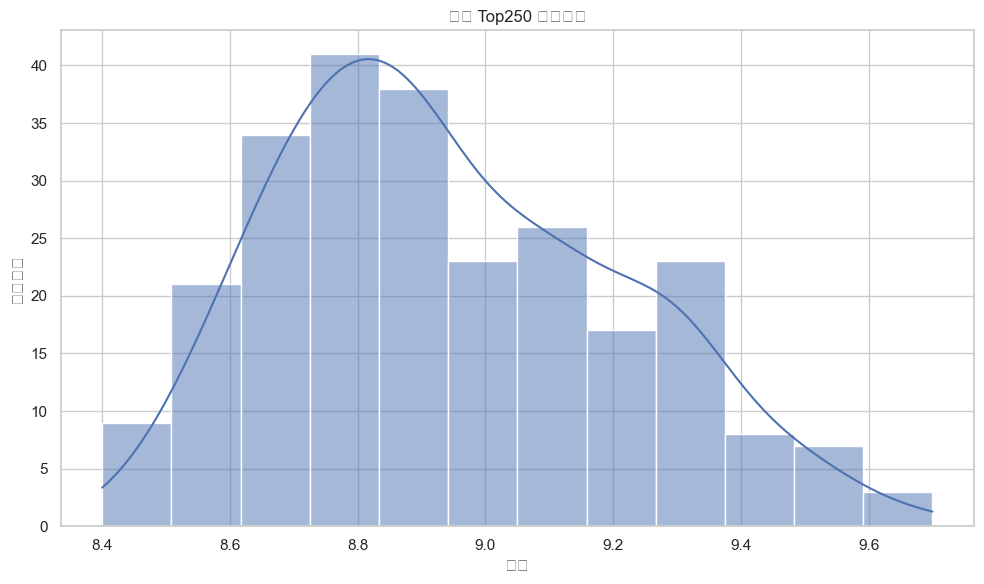

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df_movies['rating'], bins=12, kde=True)
plt.title('豆瓣 Top250 评分分布')
plt.xlabel('评分')
plt.ylabel('电影数量')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rating_distribution.png', dpi=150)
plt.show()

C:\Users\22857\AppData\Local\Temp\ipykernel_43888\2315528472.py:8: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\2315528472.py:8: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\2315528472.py:8: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\2315528472.py:8: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\2315528472.py:8: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\2315528472.py:8: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missi

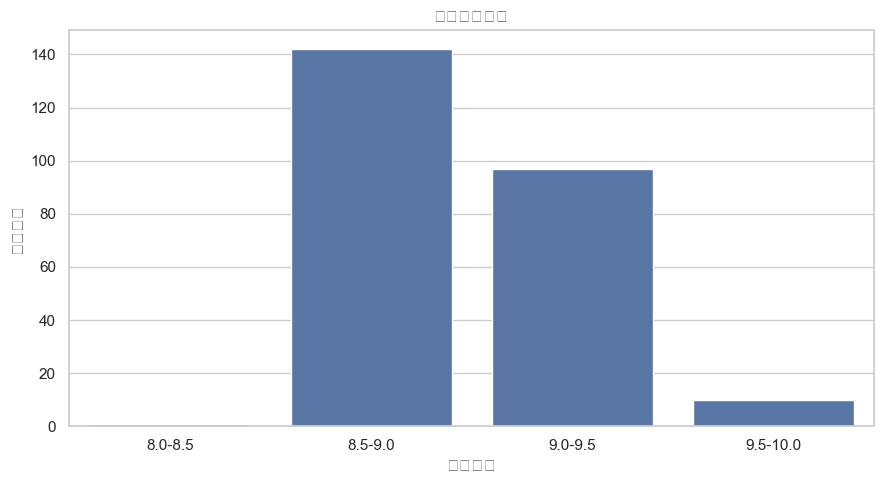

In [14]:
rating_bin_counts = df_movies['rating_bin'].value_counts().sort_index()

plt.figure(figsize=(9, 5))
sns.barplot(x=rating_bin_counts.index.astype(str), y=rating_bin_counts.values)
plt.title('评分区间分布')
plt.xlabel('评分区间')
plt.ylabel('电影数量')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rating_bin_distribution.png', dpi=150)
plt.show()

C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1808570588.py:6: UserWarning: Glyph 27036 (\N{CJK UNIFIED IDEOGRAPH-699C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1808570588.py:6: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1808570588.py:6: UserWarning: Glyph 25490 (\N{CJK UNIFIED IDEOGRAPH-6392}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1808570588.py:6: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1808570588.py:6: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1808570588.py:6: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missi

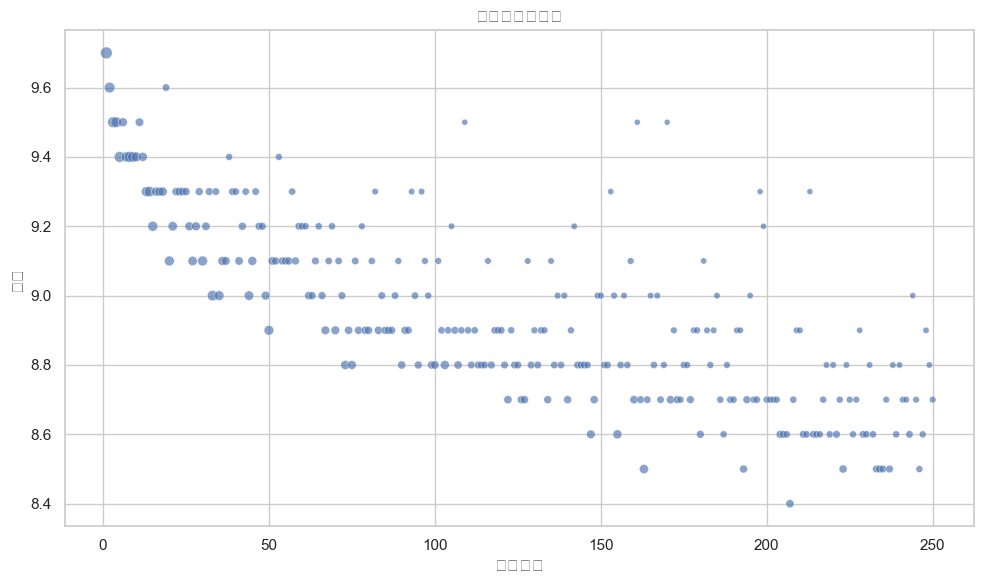

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_movies, x='movie_rank', y='rating', size='rating_count', alpha=0.65, legend=False)
plt.title('排名与评分关系')
plt.xlabel('榜单排名')
plt.ylabel('评分')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rank_vs_rating.png', dpi=150)
plt.show()

C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1916464362.py:6: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1916464362.py:6: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1916464362.py:6: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1916464362.py:6: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1916464362.py:6: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\1916464362.py:6: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missi

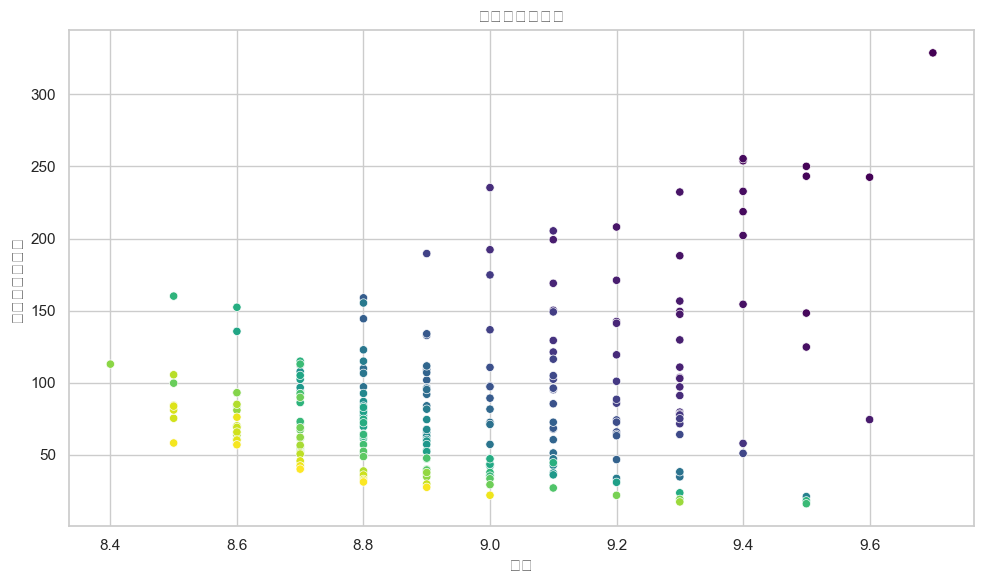

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_movies, x='rating', y='rating_count_wan', hue='movie_rank', palette='viridis', legend=False)
plt.title('评分与热度关系')
plt.xlabel('评分')
plt.ylabel('评价人数（万）')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rating_vs_popularity.png', dpi=150)
plt.show()

C:\Users\22857\AppData\Local\Temp\ipykernel_43888\27007685.py:8: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\27007685.py:8: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\27007685.py:8: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\27007685.py:8: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\27007685.py:8: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\22857\AppData\Local\Temp\ipykernel_43888\27007685.py:8: UserWarning: Glyph 19975 (\N{CJK UNIFIED IDEOGRAPH-4E07}) missing from font

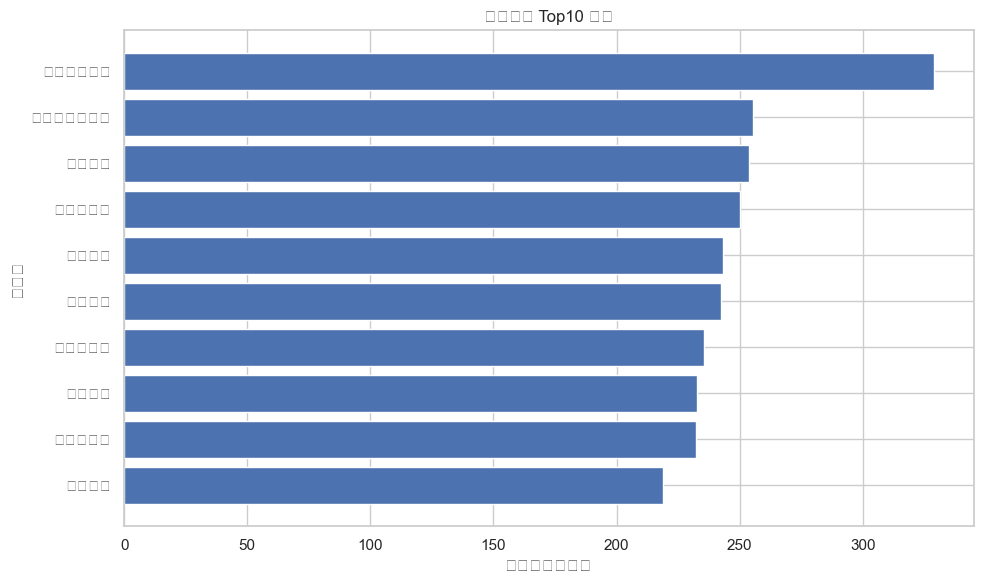

In [17]:
top10_popular = df_movies.sort_values(by='rating_count', ascending=False).head(10).sort_values(by='rating_count', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top10_popular['title_cn'], top10_popular['rating_count_wan'])
plt.title('评价人数 Top10 电影')
plt.xlabel('评价人数（万）')
plt.ylabel('电影名')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top10_popular_movies.png', dpi=150)
plt.show()

## 6. 导出分析结果表

In [18]:
analysis_export = df_movies[[
    'movie_rank', 'title_cn', 'title_other', 'rating', 'rating_count',
    'rating_count_wan', 'rating_bin', 'score_index', 'quote_text', 'crawl_time'
]].copy()

analysis_export_path_csv = OUTPUT_DIR / 'douban_top250_analysis.csv'
analysis_export_path_excel = OUTPUT_DIR / 'douban_top250_analysis.xlsx'

analysis_export.to_csv(analysis_export_path_csv, index=False, encoding='utf-8-sig')
analysis_export.to_excel(analysis_export_path_excel, index=False)

print(f'分析结果 CSV 已保存: {analysis_export_path_csv.resolve()}')
print(f'分析结果 Excel 已保存: {analysis_export_path_excel.resolve()}')

分析结果 CSV 已保存: D:\AI\App01\output\analysis\douban_top250_analysis.csv
分析结果 Excel 已保存: D:\AI\App01\output\analysis\douban_top250_analysis.xlsx


## 7. 第一版结论草稿

In [19]:
top_movie = df_movies.sort_values(by=['rating', 'rating_count'], ascending=[False, False]).iloc[0]
most_popular_movie = df_movies.sort_values(by='rating_count', ascending=False).iloc[0]

print(f"Top250 共收录 {len(df_movies)} 部电影，平均评分为 {df_movies['rating'].mean():.2f}。")
print(f"评分最高且热度靠前的电影之一是《{top_movie['title_cn']}》，评分 {top_movie['rating']}。")
print(f"评价人数最多的电影是《{most_popular_movie['title_cn']}》，约 {most_popular_movie['rating_count']:,} 人评价。")
print('你可以基于这些结果继续扩展文本分析、关键词分析和更完整的可视化报告。')

Top250 共收录 250 部电影，平均评分为 8.95。
评分最高且热度靠前的电影之一是《肖申克的救赎》，评分 9.7。
评价人数最多的电影是《肖申克的救赎》，约 3,287,797 人评价。
你可以基于这些结果继续扩展文本分析、关键词分析和更完整的可视化报告。
